# Risk-Based Allocation Strategies

Mean-variance optimization is notoriously sensitive to estimation error in expected returns. Risk-based allocation sidesteps the problem by only using the covariance matrix, spreading risk instead of capital. This notebook implements and compares two such approaches on the EURO STOXX 50 universe, with monthly rebalancing and a 2-year rolling estimation window across three covariance estimators (sample, constant-correlation shrinkage, single-factor shrinkage).

**Outline**

- **0. Setup** — data, parameters, rolling covariance estimation.
- **Part I — Equal Risk Contribution (ERC)**: closed-form sanity checks, then an out-of-sample backtest across the three covariance estimators.
- **Part II — Hierarchical Risk Parity (HRP)**: detoning intuition, a generic parametric implementation (linkage method, distance metric, allocation traversal), cluster stability across rebalances via the Rand index, and sensitivity of the resulting weights to the clustering and allocation choices.
- **Part III — Connecting the dots**: ERC vs. HRP head-to-head — robustness to the covariance estimator, performance/vol/drawdown/turnover, and the impact of transaction costs on the turnover difference between the two.

## 0. Setup


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.metrics import rand_score

from utilities.backtest import backtest, portfolio_returns
from utilities.covariance_utilities import (
    prepare_rolling_estimation_window,
    covariance_to_correlation,
    risk_contribution,
)
from utilities.hierarchical_clustering import hierarchical_clustering
from utilities.hierarchical_risk_parity import (
    correlation_to_hrp_distance,
    dendrogram_iteration,
    hierarchical_risk_parity,
    recursive_bisection,
)
from utilities.portfolio_optimization import (
    equal_risk_contribution_portfolio,
    inverse_volatility_portfolio,
)
from utilities.principal_component_analysis import detone
from utilities.shrinkage import constant_corr_shrinkage, market_factor_shrinkage

In [2]:
# Read prices, compute daily simple returns
data_path = Path("data")
last_prices = pd.read_csv(data_path / "sx5e_underlyings.csv", index_col="Date", parse_dates=True)
performance = last_prices.pct_change().iloc[1:]

/var/folders/0x/kv43z4ks21gdh6qcxlf1zh480000gn/T/ipykernel_99206/3993996878.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  performance = last_prices.pct_change().iloc[1:]


In [3]:
# Estimation parameters
estimation_window = 252 * 2  # 2-year rolling window
min_coverage = 0.95  # asset must have >=95% non-NaN in the window
trading_days = 252

# Rebalance on the last trading day of each month
rebalance_dates = pd.DatetimeIndex(
    performance.groupby(pd.Grouper(freq="ME"))
    .apply(lambda x: x.index[-1] if len(x) > 0 else None)
    .dropna()
    .values
)

## 1. Pre-computation: rolling covariance estimators

For each rebalance date we estimate three covariance matrices on the trailing 2-year window:

- **sample** — plain `cov()`,
- **constant_corr** — Ledoit–Wolf (2003) constant-correlation shrinkage,
- **mkt_factor** — Ledoit–Wolf (2002) single-factor shrinkage with the
  equally-weighted return of the surviving universe used as the market
  proxy.

The asset universe at every rebalance is restricted to names with
≥95% non-missing observations in the window.


In [4]:
covariances = {}  # date -> {estimator_name: cov_df}
universes = {}  # date -> [tickers]

for rebalance_date in rebalance_dates:
    cur_returns, diag = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=rebalance_date,
        lookback=estimation_window,
        min_coverage=min_coverage,
        return_diagnostics=True,
    )
    if diag["row_count"] < estimation_window or cur_returns.shape[1] == 0:
        continue

    reb = rebalance_date.to_pydatetime().date()

    universes[reb] = cur_returns.columns.tolist()
    covariances[reb] = {
    "sample": cur_returns.cov().to_numpy(),
    "constant_corr": constant_corr_shrinkage(cur_returns)["shrunk_cov"].to_numpy(),
    "mkt_factor": market_factor_shrinkage(
        cur_returns, cur_returns.mean(axis=1)
    )["shrunk_cov"].to_numpy(),
}

all_dates = sorted(covariances.keys())

## Part I — Equal Risk Contribution (ERC)


### 1.b Sanity check: Risk contribution dispersion & IV ≡ ERC under a diagonal Σ


In [5]:
iv_erc_delta = {}
erc_normalized_range = {}

for date in all_dates:
    iv_w  = inverse_volatility_portfolio(covariances[date]["sample"])
    erc_w = equal_risk_contribution_portfolio(covariances[date]["sample"], ignore_objective=True)

    iv_rc  = risk_contribution(iv_w,  covariances[date]["sample"])
    erc_rc = risk_contribution(erc_w, covariances[date]["sample"])
        
    iv_erc_delta[date]        = iv_rc - erc_rc
    erc_normalized_range[date] = (erc_rc.max() - erc_rc.min()) / erc_rc.mean()

# ERC dispersion
erc_ranges = pd.Series(erc_normalized_range)
print("=== ERC Normalized Range (max-min)/mean ===")
print(erc_ranges.describe())

# delta IV - ERC 
delta_df = pd.DataFrame(
    {date: pd.Series(delta, index=universes[date]) 
     for date, delta in iv_erc_delta.items()}
).T  # dates x assets
print("\n=== IV - ERC Risk Contributions (time-averaged) ===")
print(delta_df.mean().describe())

=== ERC Normalized Range (max-min)/mean ===
count    9.900000e+01
mean     8.793039e-06
std      6.090412e-06
min      6.095320e-07
25%      3.469899e-06
50%      7.841745e-06
75%      1.343003e-05
max      2.647818e-05
dtype: float64

=== IV - ERC Risk Contributions (time-averaged) ===
count    50.000000
mean     -0.000205
std       0.003258
min      -0.008476
25%      -0.001710
50%       0.000599
75%       0.002087
max       0.004371
dtype: float64


In [6]:
# Build a diagonal covariance matrix from the sample variances
date = all_dates[0]

S = covariances[date]["sample"]
diag_cov = np.diag(np.diag(S))  # zero out all off-diagonal elements

iv_w_diag  = inverse_volatility_portfolio(diag_cov)
erc_w_diag = equal_risk_contribution_portfolio(diag_cov, pcr_tolerance=0.01)

print(np.allclose(iv_w_diag, erc_w_diag, atol=1e-4))

True


### 1.c ERC backtest across the three covariance estimators


In [7]:
# Compute ERC portfolios for each estimator
erc_portfolios = {"sample": {}, "constant_corr": {}, "mkt_factor": {}}

for reb in all_dates:
    universe = universes[reb]
    for est_name, cov in covariances[reb].items():
        try:
            w = equal_risk_contribution_portfolio(
                cov,
                pcr_tolerance=0.05,
                options={"maxiter": 5000, "ftol": 1e-15, "disp": False},
            )
        except ValueError:
            w = equal_risk_contribution_portfolio(cov, ignore_objective=True)
        erc_portfolios[est_name][reb] = pd.Series(w, index=universe)

# Convert to DataFrames (dates x assets)
erc_weights = {
    est: pd.DataFrame(weights_dict).T  # dates x assets
    for est, weights_dict in erc_portfolios.items()
}

# Backtest 
erc_cumrets = {
    est: backtest(erc_weights[est], performance)
    for est in erc_weights
}
erc_returns = {
    est: portfolio_returns(erc_weights[est], performance)
    for est in erc_weights
}

# Metrics
def turnover(weights_df: pd.DataFrame) -> pd.Series:
    """One-way turnover at each rebalance date."""
    return weights_df.diff().abs().sum(axis=1).dropna()

summary = {}
for est in erc_weights:
    ret  = erc_returns[est]
    cum  = erc_cumrets[est]
    dd   = (cum - cum.cummax()) / cum.cummax()
    vol  = ret.ewm(span=63).std() * np.sqrt(252)
    to   = turnover(erc_weights[est])

    summary[est] = {
        "Total Return (%)":  (cum.iloc[-1] - 1) * 100,
        "Avg EWM Vol (%)":   vol.mean() * 100,
        "Max Drawdown (%)":  dd.min() * 100,
        "Avg Turnover (%)":  to.mean() * 100,
    }

print(pd.DataFrame(summary).round(2))

                  sample  constant_corr  mkt_factor
Total Return (%)  104.83         104.36      104.66
Avg EWM Vol (%)    17.17          17.29       17.16
Max Drawdown (%)  -38.39         -38.55      -38.36
Avg Turnover (%)    1.96           1.78        1.96


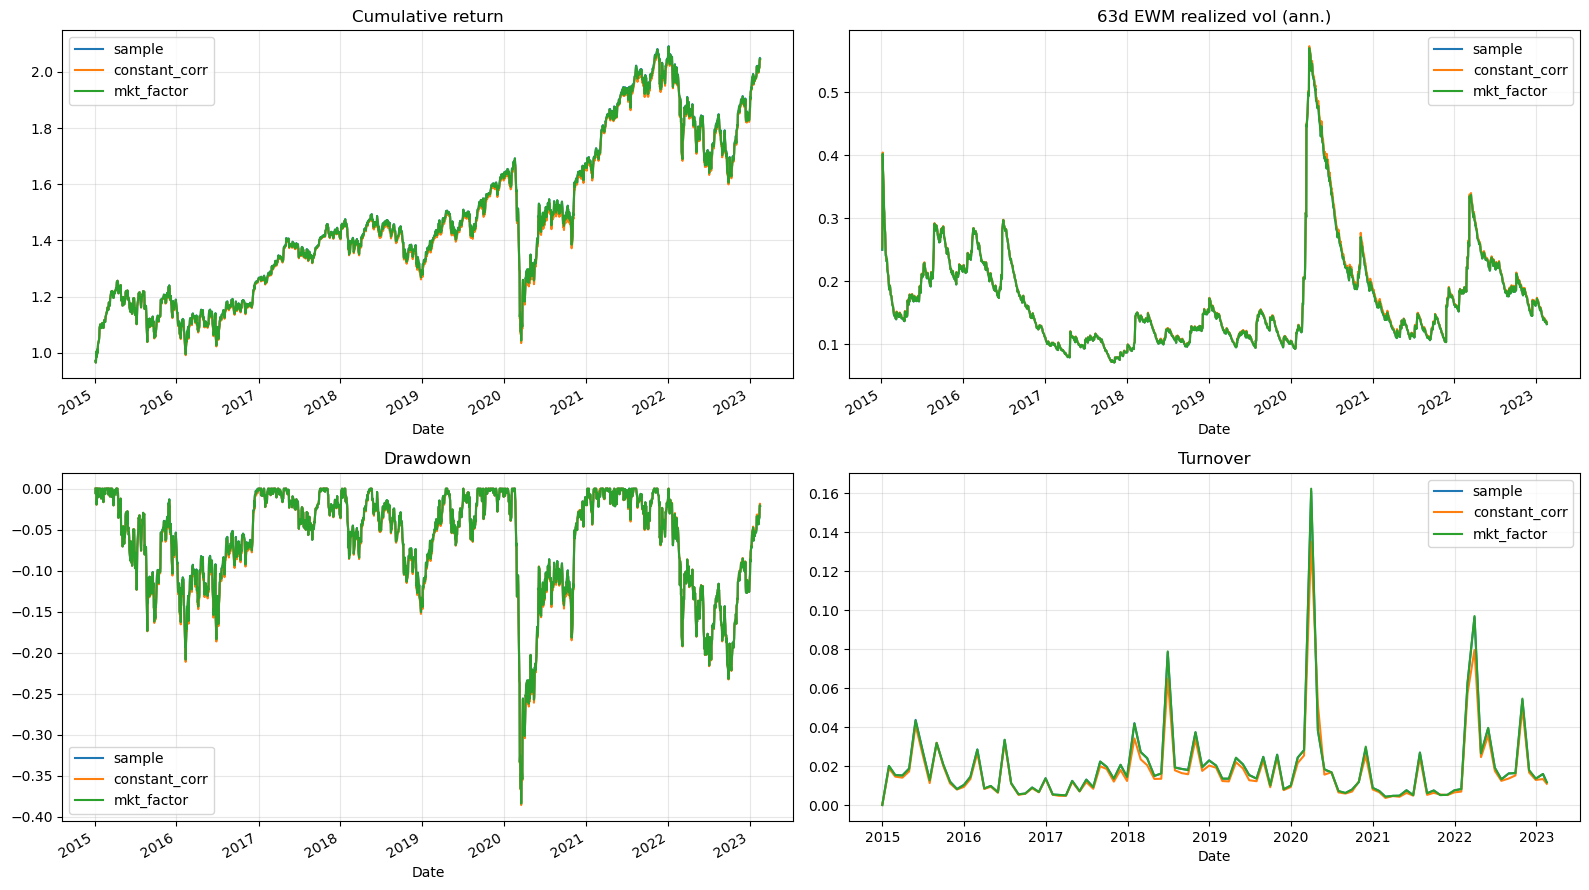

In [8]:
# Four-panel ERC backtest visualisation across the three covariance estimators
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
ax_cum, ax_vol, ax_dd, ax_to = axes.flatten()

for est in erc_weights:
    ret = erc_returns[est]
    cum = erc_cumrets[est]
    dd  = (cum - cum.cummax()) / cum.cummax()
    vol = ret.ewm(span=63).std() * np.sqrt(252)
    to  = turnover(erc_weights[est])

    cum.plot(ax=ax_cum, label=est)
    vol.plot(ax=ax_vol, label=est)
    dd.plot(ax=ax_dd,  label=est)
    to.plot(ax=ax_to,  label=est)

ax_cum.set_title("Cumulative return"); ax_cum.set_xlabel("Date"); ax_cum.legend(); ax_cum.grid(alpha=0.3)
ax_vol.set_title("63d EWM realized vol (ann.)"); ax_vol.set_xlabel("Date"); ax_vol.legend(); ax_vol.grid(alpha=0.3)
ax_dd.set_title("Drawdown"); ax_dd.set_xlabel("Date"); ax_dd.legend(); ax_dd.grid(alpha=0.3)
ax_to.set_title("Turnover"); ax_to.set_xlabel("Date"); ax_to.legend(); ax_to.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Part II — Hierarchical Risk Parity (HRP)


### 2.a Detoning — intuition


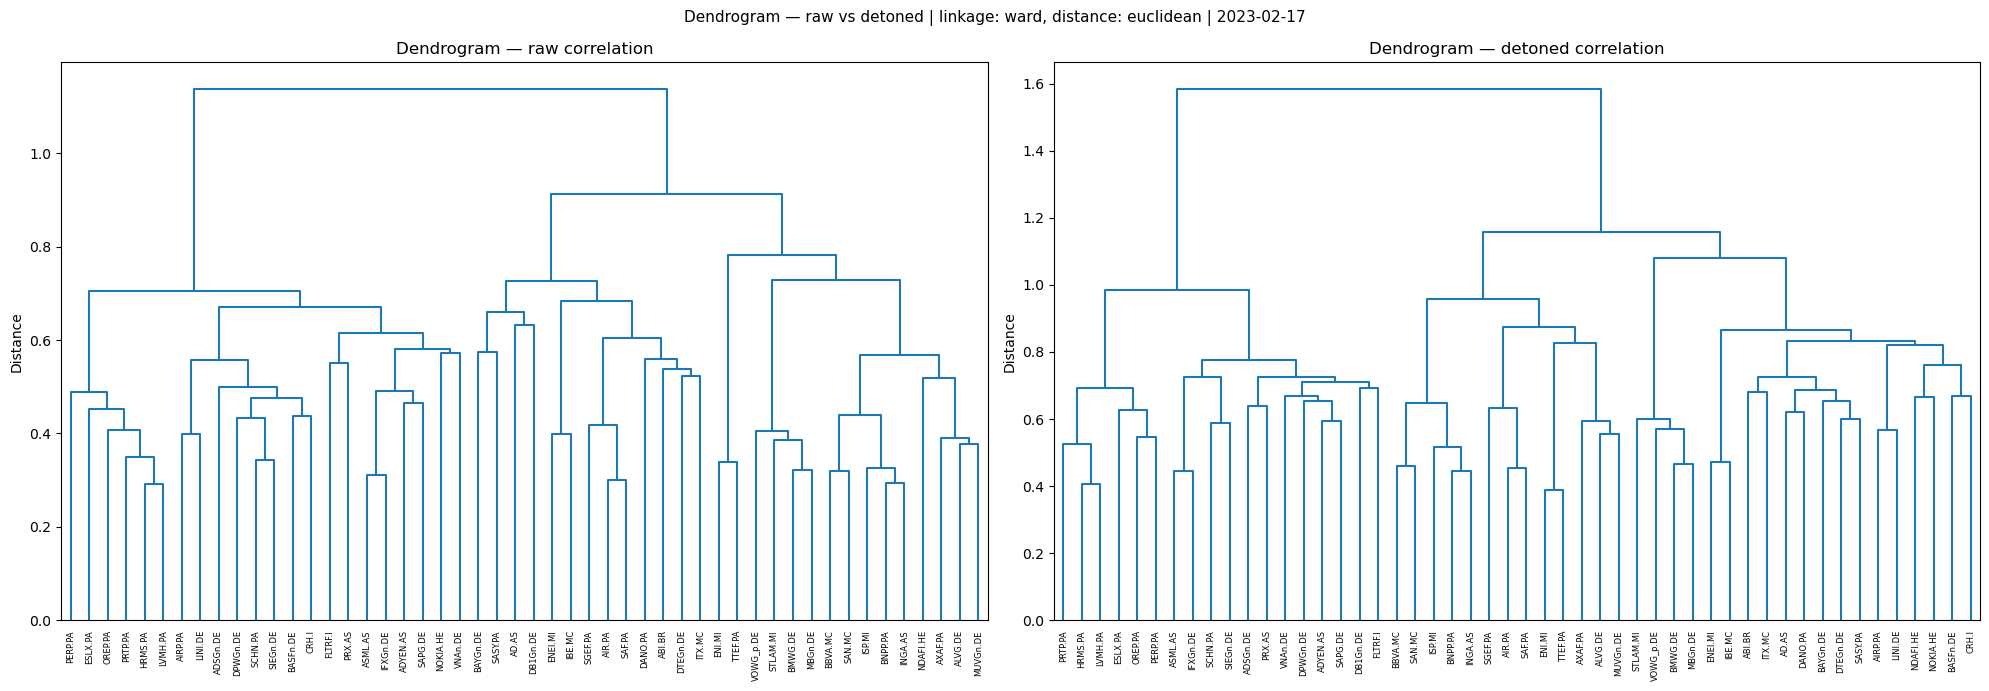

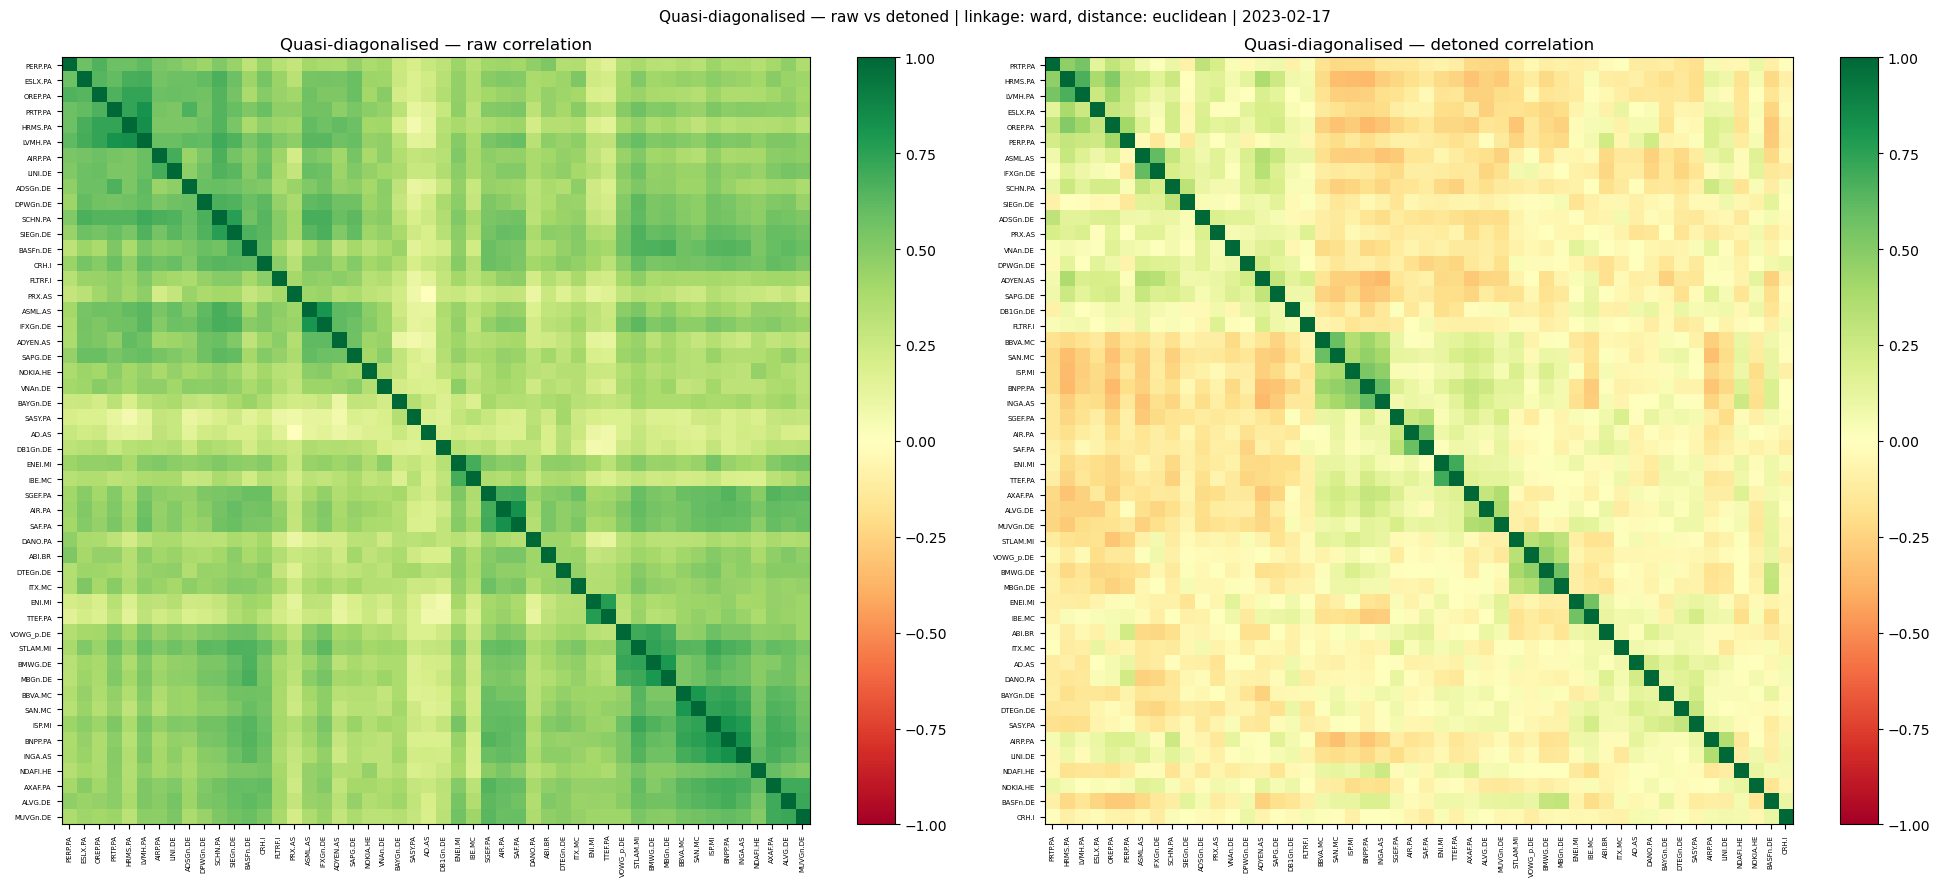

In [9]:
# Pick the last rebalance date
last_date = all_dates[-1] 

# DataFrame view of the sample covariance to carry ticker labels through the pipeline
last_cov_df = pd.DataFrame(
    covariances[last_date]["sample"],
    index=universes[last_date],
    columns=universes[last_date],
)

# Raw and detoned correlation matrices
last_corr = covariance_to_correlation(last_cov_df.values)
last_corr_detoned = detone(corr_matrix=last_corr, components_num=1)

# Wrap both correlation matrices in DataFrames to carry ticker labels through the pipeline (covariance_to_correlation and detone lose them)
last_corr_df         = pd.DataFrame(last_corr,         index=last_cov_df.index, columns=last_cov_df.columns)
last_corr_detoned_df = pd.DataFrame(last_corr_detoned, index=last_cov_df.index, columns=last_cov_df.columns)

# Build linkage matrices 
# Convert each correlation matrix to the HRP distance, then run Ward hierarchical clustering. Build both raw and detoned
dist_raw     = correlation_to_hrp_distance(last_corr)
dist_detoned = correlation_to_hrp_distance(last_corr_detoned)

link_raw = hierarchical_clustering(
    matrix=pd.DataFrame(dist_raw,     index=last_cov_df.index, columns=last_cov_df.columns),
    linkage_method="ward",
    distance_metric="euclidean",
)
link_detoned = hierarchical_clustering(
    matrix=pd.DataFrame(dist_detoned, index=last_cov_df.index, columns=last_cov_df.columns),
    linkage_method="ward",
    distance_metric="euclidean",
)

# Quasi-diagonalisation: reorder rows/cols by each dendrogram's leaf order
leaf_order_raw     = sch.leaves_list(link_raw.values)
leaf_order_detoned = sch.leaves_list(link_detoned.values)

quasi_diag_raw     = last_corr_df.iloc[leaf_order_raw,     leaf_order_raw]
quasi_diag_detoned = last_corr_detoned_df.iloc[leaf_order_detoned, leaf_order_detoned]

# --- Plot 1: Side-by-side dendrograms -----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
for ax, link, title in zip(
    axes,
    [link_raw, link_detoned],
    ["Dendrogram — raw correlation", "Dendrogram — detoned correlation"],
):
    sch.dendrogram(
        link.values,
        labels=last_cov_df.index.tolist(),
        ax=ax,
        color_threshold=0,
        leaf_rotation=90,
        leaf_font_size=6,
    )
    ax.set_title(title)
    ax.set_ylabel("Distance")

fig.suptitle(
    f"Dendrogram — raw vs detoned | linkage: ward, distance: euclidean | {last_date}",
    fontsize=11,
)
plt.tight_layout()
plt.show()

# --- Plot 2: Side-by-side quasi-diagonalised correlation matrices -------------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
for ax, matrix, title in zip(
    axes,
    [quasi_diag_raw, quasi_diag_detoned],
    ["Quasi-diagonalised — raw correlation", "Quasi-diagonalised — detoned correlation"],
):
    im = ax.imshow(matrix.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_yticks(range(len(matrix.index)))
    ax.set_xticklabels(matrix.columns, rotation=90, fontsize=5)
    ax.set_yticklabels(matrix.index, fontsize=5)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

fig.suptitle(
    f"Quasi-diagonalised — raw vs detoned | linkage: ward, distance: euclidean | {last_date}",
    fontsize=11,
)
plt.tight_layout()
plt.show()

### 2.b Generic HRP — parametric implementation

We expose a generic HRP procedure parametric in linkage method, distance metric used to build the linkage matrix and volatility allocation traversal. Two traversals are considered: López de Prado's **recursive bisection**, which halves the dendrogram leaf order regardless of the actual hierarchy, and **dendrogram iteration**, which at every step splits the cluster with the largest merge distance and therefore follows the true hierarchical structure.


In [10]:
# Sanity check: HRP runs end-to-end on the last rebalance under all parametrisations
sanity_cov = pd.DataFrame(
    covariances[last_date]["sample"],
    index=universes[last_date],
    columns=universes[last_date],
)

LINK_GRID  = ["single", "ward", "complete", "average"]
ALLOC_GRID = {
    "recursive_bisection":  recursive_bisection,
    "dendrogram_iteration": dendrogram_iteration,
}

rows = []
for link in LINK_GRID:
    for alloc_name, alloc in ALLOC_GRID.items():
        for detone_flag in [False, True]:
            w = hierarchical_risk_parity(
                covariance=sanity_cov,
                linkage_method=link,
                distance_metric="euclidean",
                cluster_traverser=alloc,
                perform_detoning=detone_flag,
            )
            rows.append({
                "linkage":    link,
                "traversal":  alloc_name,
                "detoned":    detone_flag,
                "sum(w)":     w.sum(),
                "max(w)":     w.max(),
                "herfindahl": (w ** 2).sum(),
                "n_active":   (w > 1e-6).sum(),
            })

sanity_df = pd.DataFrame(rows)
print(sanity_df.round(4).to_string(index=False))

 linkage            traversal  detoned  sum(w)  max(w)  herfindahl  n_active
  single  recursive_bisection    False     1.0  0.0625      0.0299        50
  single  recursive_bisection     True     1.0  0.0638      0.0285        50
  single dendrogram_iteration    False     1.0  0.4224      0.2750        40
  single dendrogram_iteration     True     1.0  0.3168      0.1999        50
    ward  recursive_bisection    False     1.0  0.0609      0.0284        50
    ward  recursive_bisection     True     1.0  0.0514      0.0266        50
    ward dendrogram_iteration    False     1.0  0.1031      0.0436        50
    ward dendrogram_iteration     True     1.0  0.0576      0.0271        50
complete  recursive_bisection    False     1.0  0.0616      0.0281        50
complete  recursive_bisection     True     1.0  0.0578      0.0279        50
complete dendrogram_iteration    False     1.0  0.1314      0.0810        50
complete dendrogram_iteration     True     1.0  0.0993      0.0341        50

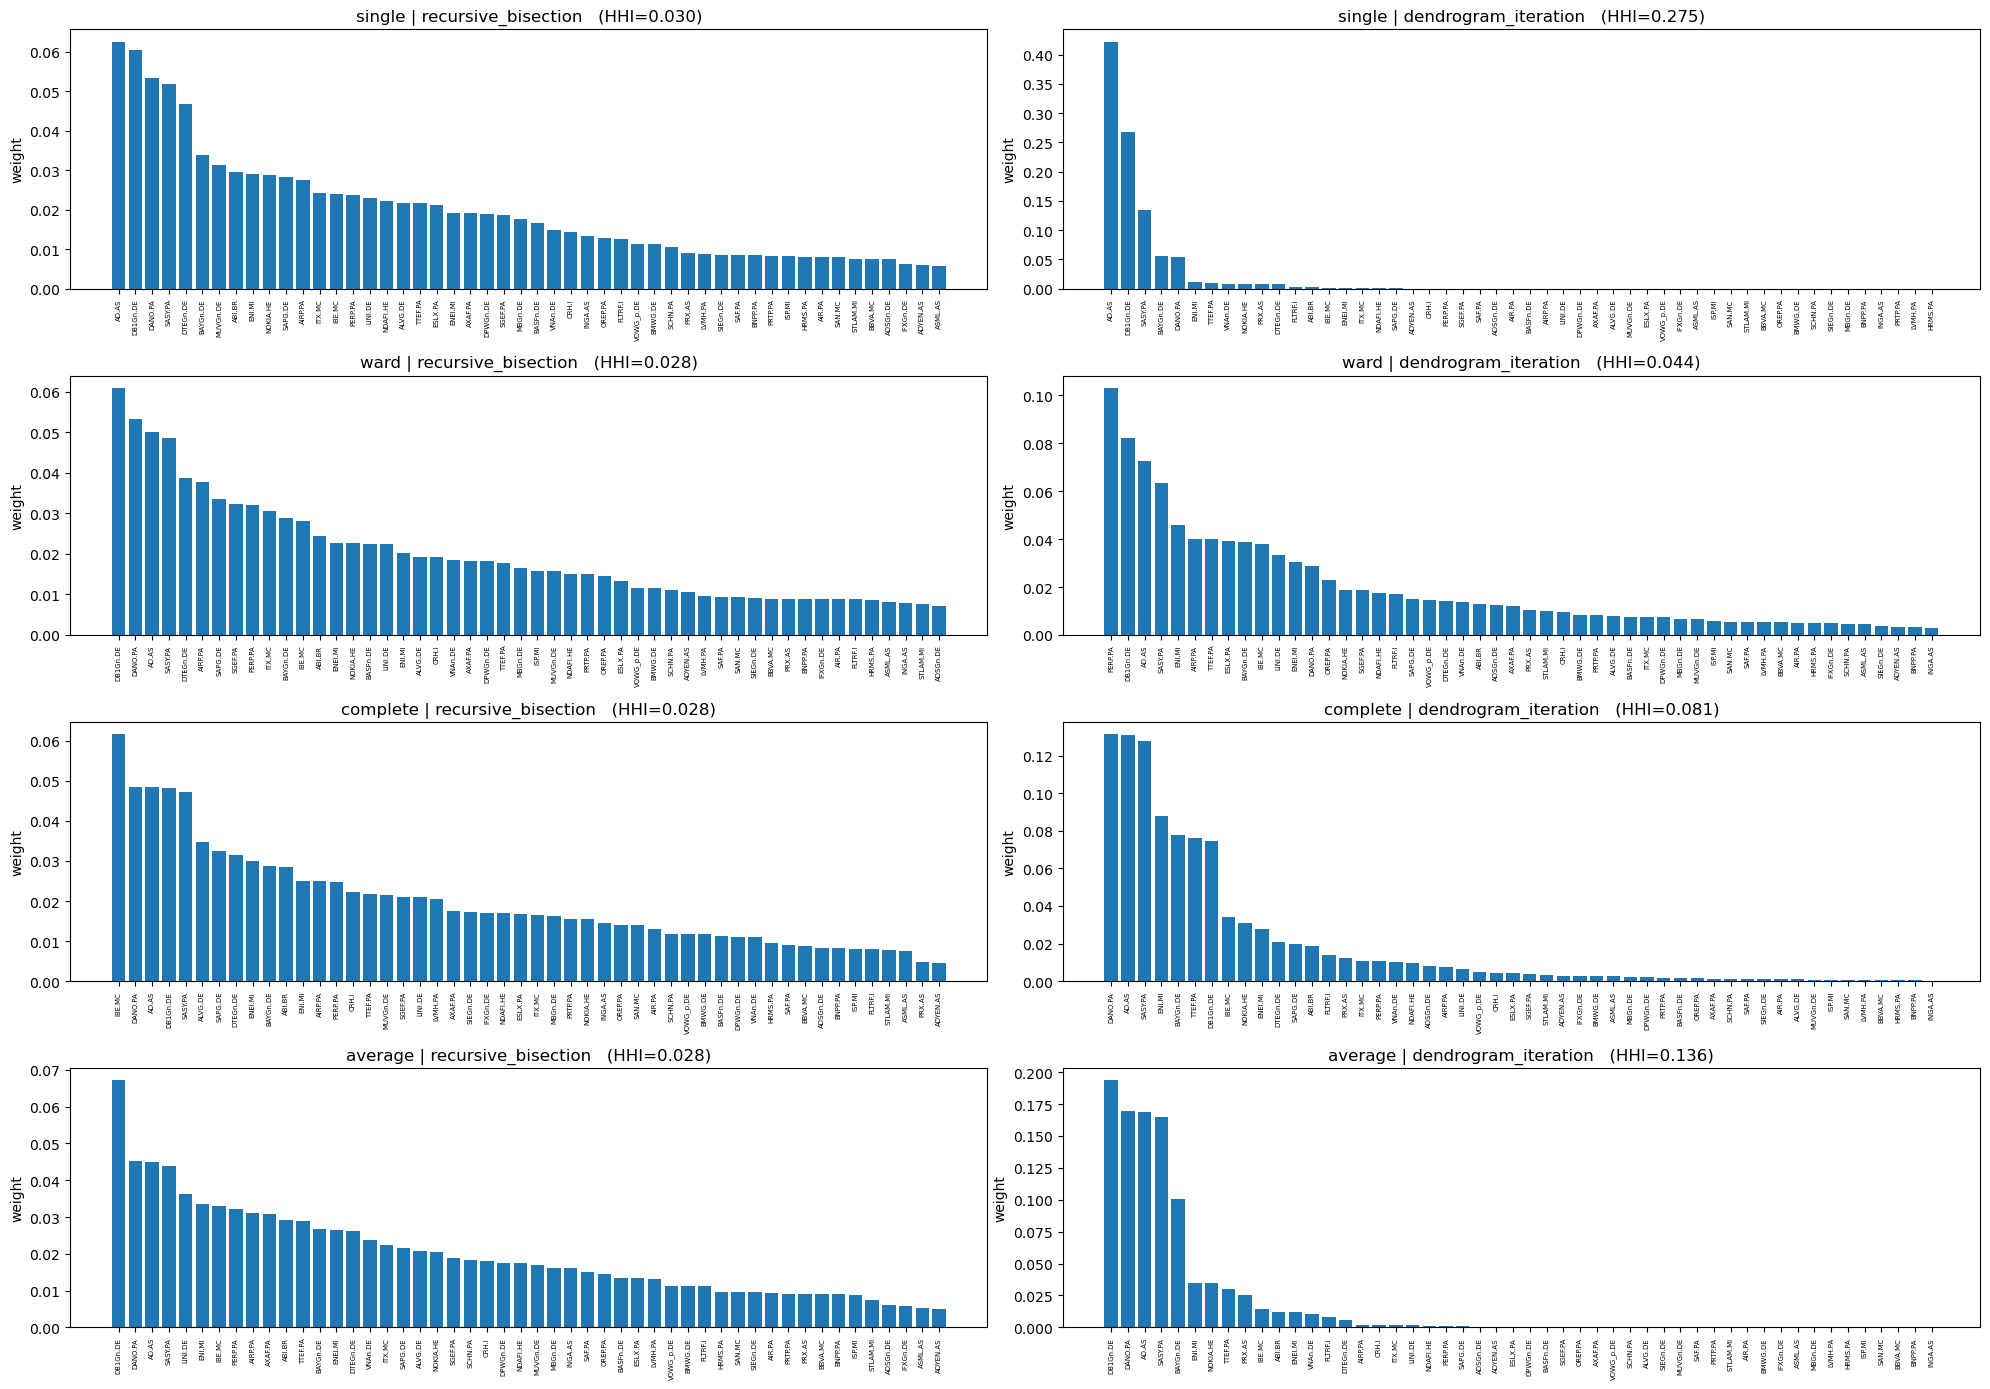

In [11]:
# HRP weights — sensitivity to linkage and allocation traversal
# Fixed: sample covariance, no detoning, last rebalance date

cov_df = pd.DataFrame(
    covariances[last_date]["sample"],
    index=universes[last_date],
    columns=universes[last_date],
)

LINK_GRID = ["single", "ward", "complete", "average"]
ALLOC_GRID = {
    "recursive_bisection":  recursive_bisection,
    "dendrogram_iteration": dendrogram_iteration,
}

fig, axes = plt.subplots(len(LINK_GRID), len(ALLOC_GRID), figsize=(20, 14))

for i, link in enumerate(LINK_GRID):
    for j, (alloc_name, alloc) in enumerate(ALLOC_GRID.items()):
        w = hierarchical_risk_parity(
            covariance=cov_df,
            linkage_method=link,
            distance_metric="euclidean",
            cluster_traverser=alloc,
            perform_detoning=False,
        )
        w_sorted = w.sort_values(ascending=False)
        hhi = float((w ** 2).sum())

        ax = axes[i, j]
        ax.bar(range(len(w_sorted)), w_sorted.values)
        ax.set_xticks(range(len(w_sorted)))
        ax.set_xticklabels(w_sorted.index, rotation=90, fontsize=5)
        ax.set_ylabel("weight")
        ax.set_title(f"{link} | {alloc_name}   (HHI={hhi:.3f})")

plt.tight_layout()
plt.show()

### 2.c Cluster stability across rebalances (Rand index)

We measure how stable the clustering is between consecutive rebalances via the Rand index. A value close to 1 means the partition into $k$ clusters changes little month-to-month.


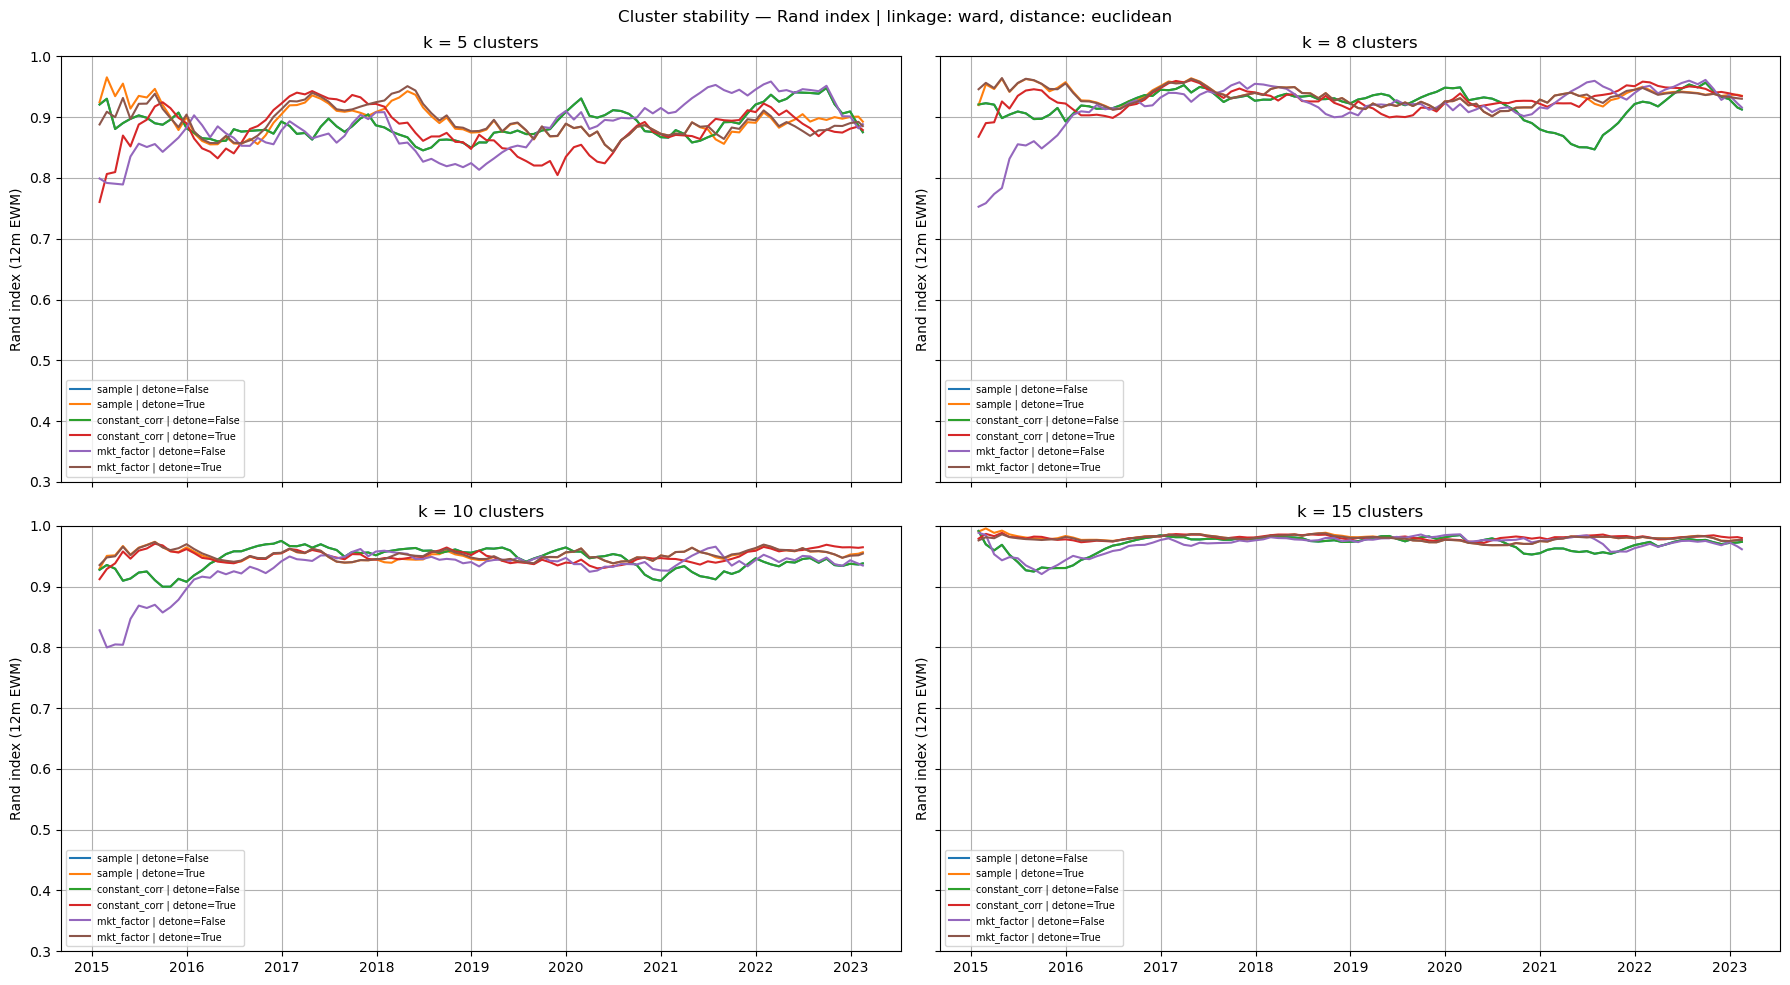

In [12]:
LINKAGE_METHOD = "ward"
DIST_METRIC = "euclidean"
N_CLUSTERS_GRID = [5, 8, 10, 15]
N_CLUSTERS_FOCUS = 10
COV_KEYS = ["sample", "constant_corr", "mkt_factor"]
DETONE_KEYS = [False, True]


linkages = {(c, d): {} for c in COV_KEYS for d in DETONE_KEYS}
clusters = {
    (c, d, k): {} for c in COV_KEYS for d in DETONE_KEYS for k in N_CLUSTERS_GRID
}

for reb in all_dates:
    for cov_key in COV_KEYS:
        cov = covariances[reb][cov_key]            
        tickers = universes[reb]                   
        for detone_flag in DETONE_KEYS:
            corr = covariance_to_correlation(cov)  
            if detone_flag:
                corr = detone(corr, components_num=1)

            dist = correlation_to_hrp_distance(corr)
            dist_df = pd.DataFrame(dist, index=tickers, columns=tickers)

            link = hierarchical_clustering(
                dist_df,
                linkage_method=LINKAGE_METHOD,
                distance_metric=DIST_METRIC,
            )
            linkages[(cov_key, detone_flag)][reb] = link
            for n_clusters in N_CLUSTERS_GRID:
                clusters[(cov_key, detone_flag, n_clusters)][reb] = pd.Series(
                    sch.cut_tree(link.values, n_clusters=n_clusters).flatten(),
                    index=tickers,
                )

rand_indices = {
    (c, d, k): {} for c in COV_KEYS for d in DETONE_KEYS for k in N_CLUSTERS_GRID
}

for cov_key in COV_KEYS:
    for detone_flag in DETONE_KEYS:
        for n_clusters in N_CLUSTERS_GRID:
            cluster_series = clusters[(cov_key, detone_flag, n_clusters)]
            dates = sorted(cluster_series.keys())
            for t_prev, t_curr in zip(dates[:-1], dates[1:]):
                labels_prev = cluster_series[t_prev]
                labels_curr = cluster_series[t_curr]
                # Restrict to assets present in both dates (the universe can change).
                common = labels_prev.index.intersection(labels_curr.index)
                rand_indices[(cov_key, detone_flag, n_clusters)][t_curr] = rand_score(
                    labels_prev.loc[common],
                    labels_curr.loc[common],
                )

# Convert into Series and smooth with EWM to 12 monthly observations
rand_index_ewm = {
    key: pd.Series(vals).ewm(span=12).mean()
    for key, vals in rand_indices.items()
}

# Plot the 12m EWM smoothed Rand index time series
# One subplot per number of clusters, one line per (cov_key, detone_flag) combination
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True, sharey=True)

for ax, n_clusters in zip(axes.flatten(), N_CLUSTERS_GRID):
    for cov_key in COV_KEYS:
        for detone_flag in DETONE_KEYS:
            series = rand_index_ewm[(cov_key, detone_flag, n_clusters)]
            label = f"{cov_key} | detone={detone_flag}"
            ax.plot(series.index, series.values, label=label)
    
    ax.set_title(f"k = {n_clusters} clusters")
    ax.set_ylabel("Rand index (12m EWM)")
    ax.set_ylim(0.3, 1)
    ax.legend(fontsize=7)
    ax.grid(True)

fig.suptitle(
    f"Cluster stability — Rand index | linkage: {LINKAGE_METHOD}, distance: {DIST_METRIC}",
    fontsize=12,
)
plt.tight_layout()
plt.show()

In [13]:
# Time-averaged Rand index per (estimator, detoning, k)
summary_rand = pd.DataFrame(
    {
        f"k={k}": {
            f"{cov_key} | detone={d}": pd.Series(rand_indices[(cov_key, d, k)]).mean()
            for cov_key in COV_KEYS
            for d in DETONE_KEYS
        }
        for k in N_CLUSTERS_GRID
    }
)

print("=== Mean Rand index across rebalances ===")
print(summary_rand.round(3))

=== Mean Rand index across rebalances ===
                                k=5    k=8   k=10   k=15
sample | detone=False         0.887  0.920  0.944  0.970
sample | detone=True          0.891  0.934  0.951  0.979
constant_corr | detone=False  0.887  0.920  0.944  0.970
constant_corr | detone=True   0.879  0.930  0.951  0.981
mkt_factor | detone=False     0.886  0.922  0.935  0.970
mkt_factor | detone=True      0.891  0.933  0.952  0.979


### 2.d Sensitivity of HRP weights — clustering vs. allocation traversal


In [14]:
from utilities.hierarchical_risk_parity import (
    top_down_allocation,
    get_cluster_var_via_iv,
)
from joblib import Parallel, delayed

LINK_GRID = ["single", "ward", "complete", "average"]
ALLOC_GRID = {
    "recursive_bisection": recursive_bisection,
    "dendrogram_iteration": dendrogram_iteration,
}

# Worker: handles one (estimator, linkage, detoning) triplet, computing weights
# for BOTH allocators inside the same process. The linkage matrix is built once
# per rebalance and reused across the two allocators.
def compute_variant_pair(cov_key, link, d):
    weights_per_allocator = {alloc_name: {} for alloc_name in ALLOC_GRID}

    for reb in all_dates:
        cov_arr = covariances[reb][cov_key]   # ndarray (notebook convention)
        tickers = universes[reb]              # list[str]
        cov_df = pd.DataFrame(cov_arr, index=tickers, columns=tickers)

        # Correlation, optional detoning, HRP distance
        corr = covariance_to_correlation(cov_arr)
        if d:
            corr = detone(corr, components_num=1)
        dist_df = pd.DataFrame(
            correlation_to_hrp_distance(corr),
            index=tickers,
            columns=tickers,
        )

        # Single linkage matrix shared between the two allocators
        link_mat = hierarchical_clustering(
            matrix=dist_df,
            linkage_method=link,
            distance_metric=DIST_METRIC,
        )

        for alloc_name, alloc in ALLOC_GRID.items():
            nested = alloc(link_mat, labels=tickers)
            weights_per_allocator[alloc_name][reb] = top_down_allocation(
                nested_clusters=nested,
                covariance=cov_df,
                get_cluster_var=get_cluster_var_via_iv,
            )

    return {
        (cov_key, link, alloc_name, d): weights_per_allocator[alloc_name]
        for alloc_name in ALLOC_GRID
    }

# 24 independent triplets dispatched across all available cores
parallel_results = Parallel(n_jobs=-1, verbose=5, backend="loky")(
    delayed(compute_variant_pair)(cov_key, link, d)
    for cov_key in COV_KEYS
    for link in LINK_GRID
    for d in DETONE_KEYS
)

hrp_grid = {}
for partial in parallel_results:
    hrp_grid.update(partial)

# Convert each variant into a (dates x assets) weights DataFrame.
# fillna(0) so that an asset entering / exiting the universe contributes its
# full weight to one-way turnover (cash-funded rebalancing convention).
hrp_weights_dfs = {
    key: pd.DataFrame(history).T.sort_index().fillna(0.0)
    for key, history in hrp_grid.items()
}

# Mean one-way turnover and mean Herfindahl concentration per variant
def variant_summary(weights_df: pd.DataFrame) -> dict:
    """Mean one-way turnover and mean HHI over rebalances."""
    return {
        "mean_turnover": turnover(weights_df).mean(),
        "mean_hhi":      (weights_df ** 2).sum(axis=1).mean(),
    }

summary_rows = [
    {
        "estimator": cov_key,
        "linkage": link,
        "allocator": alloc_name,
        "detoned": d,
        **variant_summary(wdf),
    }
    for (cov_key, link, alloc_name, d), wdf in hrp_weights_dfs.items()
]
hrp_summary = (
    pd.DataFrame(summary_rows)
    .sort_values(["allocator", "linkage", "estimator", "detoned"])
    .reset_index(drop=True)
)

turnover_pivot = hrp_summary.pivot_table(
    index=["allocator", "linkage"],
    columns=["estimator", "detoned"],
    values="mean_turnover",
).round(4)
hhi_pivot = hrp_summary.pivot_table(
    index=["allocator", "linkage"],
    columns=["estimator", "detoned"],
    values="mean_hhi",
).round(4)

print("=== Mean one-way turnover ===")
print(turnover_pivot)
print("\n=== Mean Herfindahl concentration index (HHI) ===")
print(hhi_pivot)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   19.4s


[Parallel(n_jobs=-1)]: Done  14 out of  24 | elapsed:   37.5s remaining:   26.8s


[Parallel(n_jobs=-1)]: Done  19 out of  24 | elapsed:   54.0s remaining:   14.2s


[Parallel(n_jobs=-1)]: Done  24 out of  24 | elapsed:   54.5s finished


=== Mean one-way turnover ===
estimator                     constant_corr         mkt_factor          \
detoned                               False   True       False   True    
allocator            linkage                                             
dendrogram_iteration average         0.2693  0.3243     0.2236  0.2973   
                     complete        0.3315  0.4079     0.3361  0.3903   
                     single          0.1589  0.3787     0.1720  0.3898   
                     ward            0.3574  0.3619     0.3406  0.3620   
recursive_bisection  average         0.1974  0.2071     0.2034  0.1967   
                     complete        0.2157  0.2346     0.2312  0.2294   
                     single          0.1733  0.2232     0.1703  0.2269   
                     ward            0.2213  0.2126     0.2220  0.2108   

estimator                      sample          
detoned                         False   True   
allocator            linkage                   
dendrogram_

## Part III — Connecting the Dots


### 3.a ERC vs HRP — Robustness Against Estimator Choice

=== Mean L1 distance between weight schedules under different estimators ===
                             ERC  \
Sample vs Const.Corr      0.0316   
Sample vs Mkt.Factor      0.0030   
Const.Corr vs Mkt.Factor  0.0316   
mean of pairs             0.0221   

                          HRP (ward + dendrogram_iteration + detoning=on)  
Sample vs Const.Corr                                               0.2528  
Sample vs Mkt.Factor                                               0.0412  
Const.Corr vs Mkt.Factor                                           0.2556  
mean of pairs                                                      0.1832  


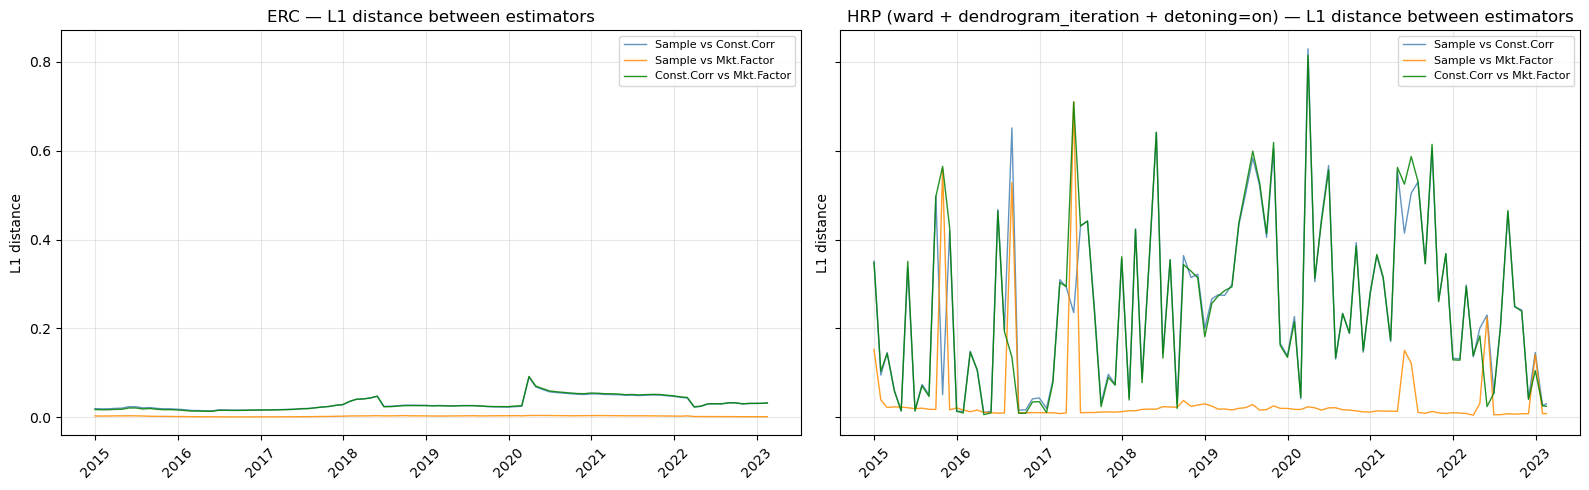

In [15]:
# === 3.a — Robustness to covariance estimator choice ===

# Representative HRP strategy: ward + dendrogram_iteration + detoning=True.
# This adopts the best-practice findings from Part II:
#   - ward linkage gives balanced dendrograms (2.d);
#   - dendrogram_iteration follows the actual hierarchy and lets estimator-
#     driven differences propagate fully to weights (most rigorous test);
#   - detoning improves cluster stability across rebalances (2.c).
HRP_LINK = "ward"
HRP_ALLOC = "dendrogram_iteration"
HRP_DETONE = True
HRP_REP_LABEL = f"HRP ({HRP_LINK} + {HRP_ALLOC} + detoning={'on' if HRP_DETONE else 'off'})"

# HRP weights DataFrames per estimator (re-use cached 2.d output)
hrp_weights_by_estimator = {
    est: hrp_weights_dfs[(est, HRP_LINK, HRP_ALLOC, HRP_DETONE)]
    for est in COV_KEYS
}


def pairwise_l1_series(weights_a: pd.DataFrame, weights_b: pd.DataFrame) -> pd.Series:
    """Time series of L1 distance between two weight schedules on the common universe."""
    common_dates = weights_a.index.intersection(weights_b.index)
    common_assets = weights_a.columns.intersection(weights_b.columns)
    a = weights_a.loc[common_dates, common_assets].fillna(0.0)
    b = weights_b.loc[common_dates, common_assets].fillna(0.0)
    return (a - b).abs().sum(axis=1)


estimator_pairs = [
    ("sample", "constant_corr"),
    ("sample", "mkt_factor"),
    ("constant_corr", "mkt_factor"),
]
pair_labels = {
    ("sample", "constant_corr"):     "Sample vs Const.Corr",
    ("sample", "mkt_factor"):        "Sample vs Mkt.Factor",
    ("constant_corr", "mkt_factor"): "Const.Corr vs Mkt.Factor",
}
pair_colors = {
    ("sample", "constant_corr"):     "steelblue",
    ("sample", "mkt_factor"):        "darkorange",
    ("constant_corr", "mkt_factor"): "green",
}

# L1 distance time series per pair, per strategy
erc_l1_series = {
    pair: pairwise_l1_series(erc_weights[pair[0]], erc_weights[pair[1]])
    for pair in estimator_pairs
}
hrp_l1_series = {
    pair: pairwise_l1_series(
        hrp_weights_by_estimator[pair[0]], hrp_weights_by_estimator[pair[1]]
    )
    for pair in estimator_pairs
}

# Robustness summary table
robustness_table = pd.DataFrame(
    index=[pair_labels[p] for p in estimator_pairs] + ["mean of pairs"],
    columns=["ERC", HRP_REP_LABEL],
    dtype=float,
)
for pair in estimator_pairs:
    robustness_table.loc[pair_labels[pair], "ERC"] = erc_l1_series[pair].mean()
    robustness_table.loc[pair_labels[pair], HRP_REP_LABEL] = hrp_l1_series[pair].mean()
robustness_table.loc["mean of pairs"] = robustness_table.iloc[:-1].mean()

print("=== Mean L1 distance between weight schedules under different estimators ===")
print(robustness_table.round(4))

# L1 distance time series: ERC (left) vs HRP (right)
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for pair in estimator_pairs:
    s = erc_l1_series[pair]
    axes[0].plot(s.index, s.values, label=pair_labels[pair],
                 color=pair_colors[pair], linewidth=1, alpha=0.85)
axes[0].set_title("ERC — L1 distance between estimators")
axes[0].set_ylabel("L1 distance")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[0].tick_params(axis="x", rotation=45)

for pair in estimator_pairs:
    s = hrp_l1_series[pair]
    axes[1].plot(s.index, s.values, label=pair_labels[pair],
                 color=pair_colors[pair], linewidth=1, alpha=0.85)
axes[1].set_title(f"{HRP_REP_LABEL} — L1 distance between estimators")
axes[1].set_ylabel("L1 distance")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 3.b ERC vs HRP — performance, vol, drawdown, turnover


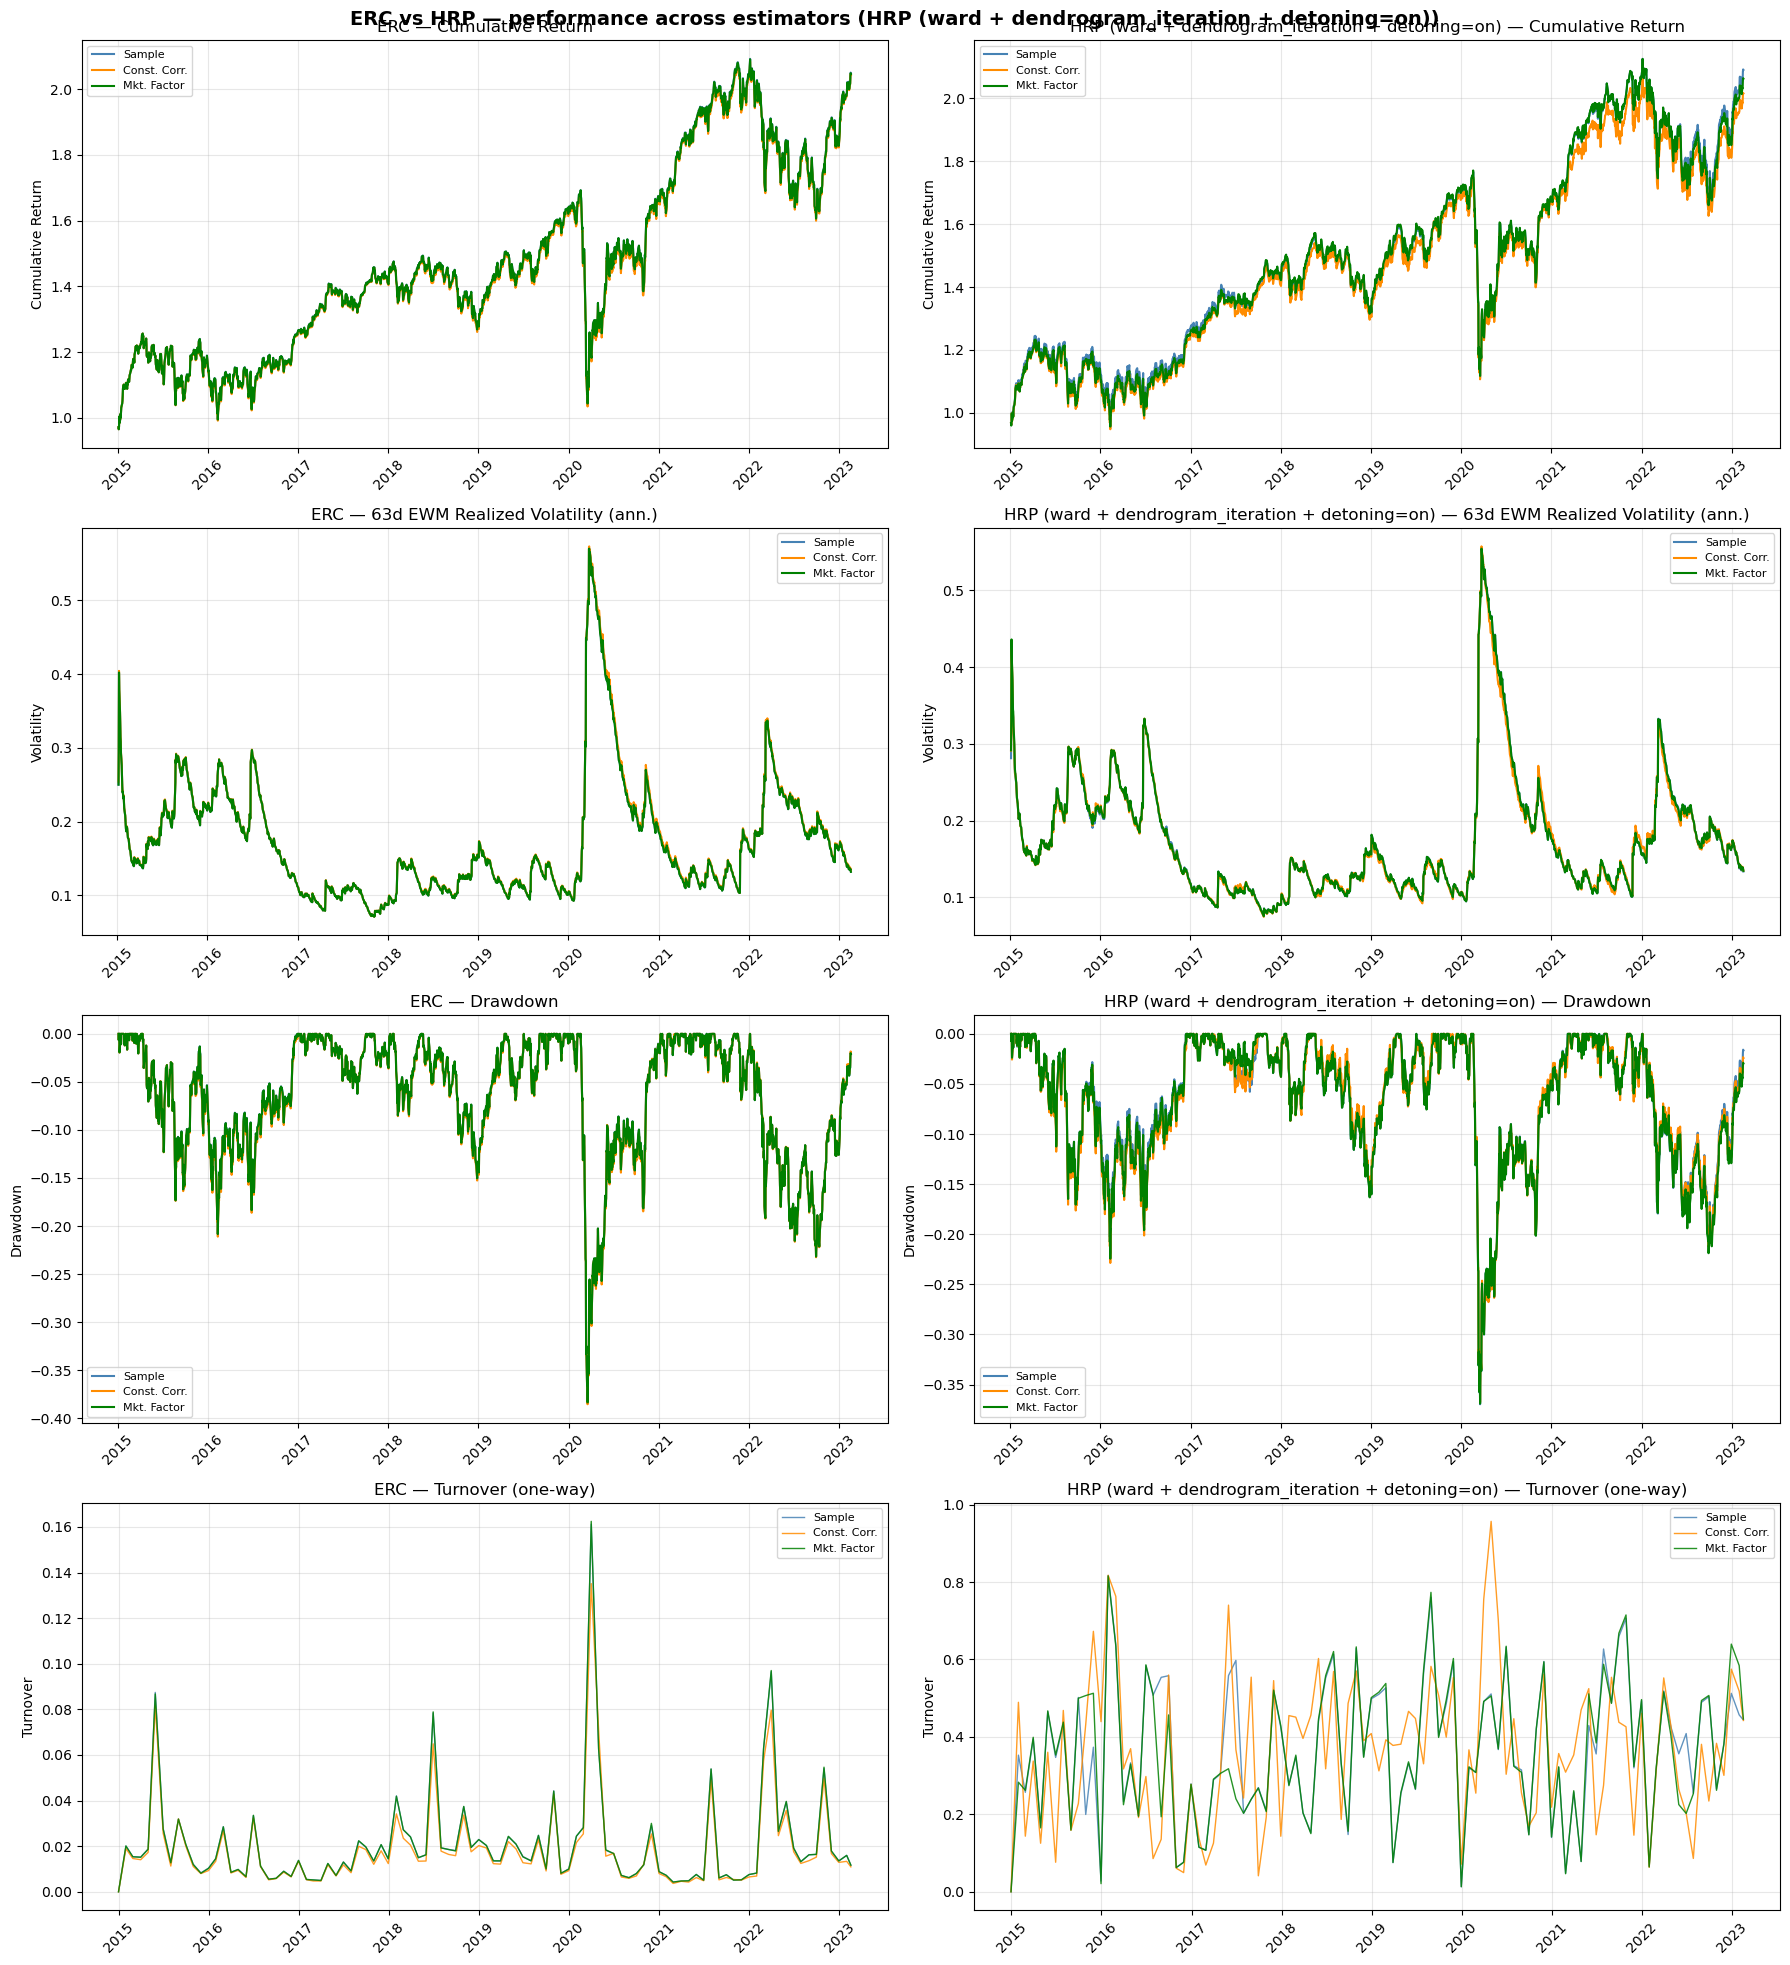

                                            Sample     Const.Corr     Mkt.Factor

--- ERC ---
Total Return (%)                            104.83         104.36         104.66
Avg EWM Vol (%)                              17.17          17.29          17.16
Max Drawdown (%)                            -38.39         -38.55         -38.36
Avg Turnover (%)                              2.07           1.88           2.07

--- HRP (ward + dendrogram_iteration + detoning=on) ---
Total Return (%)                            109.04         101.56         106.25
Avg EWM Vol (%)                              17.37          17.30          17.38
Max Drawdown (%)                            -36.96         -36.75         -36.89
Avg Turnover (%)                             36.81          36.19          36.20



In [16]:
# === 3.b — ERC vs HRP performance head-to-head (per estimator) ===

# Local helpers
def realized_volatility_ewm(returns_series: pd.Series, span: int = 63) -> pd.Series:
    """Annualised realized volatility via exponentially-weighted std."""
    return returns_series.ewm(span=span).std() * np.sqrt(trading_days)

def drawdown(cum_returns: pd.Series) -> pd.Series:
    """Drawdown series from a cumulative-return path."""
    return (cum_returns - cum_returns.cummax()) / cum_returns.cummax()

# HRP returns and cumulative returns per estimator (representative variant)
hrp_returns_by_est = {
    est: portfolio_returns(hrp_weights_by_estimator[est], performance)
    for est in COV_KEYS
}
hrp_cumrets_by_est = {
    est: backtest(hrp_weights_by_estimator[est], performance)
    for est in COV_KEYS
}

# Aesthetics — keys aligned to the actual notebook's estimator names
estimator_colors = {
    "sample":        "steelblue",
    "constant_corr": "darkorange",
    "mkt_factor":    "green",
}
estimator_display = {
    "sample":        "Sample",
    "constant_corr": "Const. Corr.",
    "mkt_factor":    "Mkt. Factor",
}

# 4 rows (metrics) x 2 columns (strategies); 3 lines per panel (one per estimator)
strategies = [
    ("ERC",         erc_cumrets,         erc_returns,         erc_weights),
    (HRP_REP_LABEL, hrp_cumrets_by_est,  hrp_returns_by_est,  hrp_weights_by_estimator),
]

fig, axes = plt.subplots(4, 2, figsize=(18, 20))
fig.suptitle(
    f"ERC vs HRP — performance across estimators ({HRP_REP_LABEL})",
    fontsize=14, fontweight="bold",
)

for col, (strat_name, cumrets, rets, weights_dict) in enumerate(strategies):
    # Row 0 — Cumulative return
    for est in COV_KEYS:
        axes[0, col].plot(cumrets[est], color=estimator_colors[est],
                          label=estimator_display[est], linewidth=1.5)
    axes[0, col].set_title(f"{strat_name} — Cumulative Return")
    axes[0, col].set_ylabel("Cumulative Return")
    axes[0, col].legend(fontsize=8); axes[0, col].grid(alpha=0.3)

    # Row 1 — 63d EWM realized volatility (annualised)
    for est in COV_KEYS:
        vol = realized_volatility_ewm(rets[est], span=63)
        axes[1, col].plot(vol, color=estimator_colors[est],
                          label=estimator_display[est], linewidth=1.5)
    axes[1, col].set_title(f"{strat_name} — 63d EWM Realized Volatility (ann.)")
    axes[1, col].set_ylabel("Volatility")
    axes[1, col].legend(fontsize=8); axes[1, col].grid(alpha=0.3)

    # Row 2 — Drawdown
    for est in COV_KEYS:
        dd = drawdown(cumrets[est])
        axes[2, col].plot(dd, color=estimator_colors[est],
                          label=estimator_display[est], linewidth=1.5)
    axes[2, col].set_title(f"{strat_name} — Drawdown")
    axes[2, col].set_ylabel("Drawdown")
    axes[2, col].legend(fontsize=8); axes[2, col].grid(alpha=0.3)

    # Row 3 — One-way turnover (cash-funded convention via fillna(0))
    for est in COV_KEYS:
        wdf = weights_dict[est].fillna(0.0)
        to = turnover(wdf)
        axes[3, col].plot(to, color=estimator_colors[est],
                          label=estimator_display[est], linewidth=1, alpha=0.85)
    axes[3, col].set_title(f"{strat_name} — Turnover (one-way)")
    axes[3, col].set_ylabel("Turnover")
    axes[3, col].legend(fontsize=8); axes[3, col].grid(alpha=0.3)

for ax in axes.flatten():
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Numeric summary
print("=" * 90)
print(f"{'':<35}{'Sample':>15}{'Const.Corr':>15}{'Mkt.Factor':>15}")
print("=" * 90)
for strat_name, cumrets, rets, weights_dict in strategies:
    print(f"\n--- {strat_name} ---")
    print(f"{'Total Return (%)':<35}", end="")
    for est in COV_KEYS:
        print(f"{(cumrets[est].iloc[-1] - 1) * 100:>15.2f}", end="")
    print()
    print(f"{'Avg EWM Vol (%)':<35}", end="")
    for est in COV_KEYS:
        print(f"{realized_volatility_ewm(rets[est]).mean() * 100:>15.2f}", end="")
    print()
    print(f"{'Max Drawdown (%)':<35}", end="")
    for est in COV_KEYS:
        print(f"{drawdown(cumrets[est]).min() * 100:>15.2f}", end="")
    print()
    print(f"{'Avg Turnover (%)':<35}", end="")
    for est in COV_KEYS:
        wdf = weights_dict[est].fillna(0.0)
        print(f"{turnover(wdf).mean() * 100:>15.2f}", end="")
    print()
print("\n" + "=" * 90)

### 3.c Impact of transaction costs

Gross performance alone can be misleading: HRP and ERC can look similar before costs while differing a lot in turnover. Using the drift-aware turnover (comparing the new target against the previous target drifted by realized returns, not frozen weights), we re-run both strategies net of a realistic 10bps all-in transaction cost to see whether the higher HRP turnover seen in 2.d actually shows up as a performance drag relative to ERC.

=== Gross vs net of 10bps transaction costs ===
                                                              Total Return gross (%)  \
Strategy                                        Estimator                              
ERC                                             Sample                        104.83   
                                                Const. Corr.                  104.36   
                                                Mkt. Factor                   104.66   
HRP (ward + dendrogram_iteration + detoning=on) Sample                        109.04   
                                                Const. Corr.                  101.56   
                                                Mkt. Factor                   106.25   

                                                              Total Return net (%)  \
Strategy                                        Estimator                            
ERC                                             Sample                     

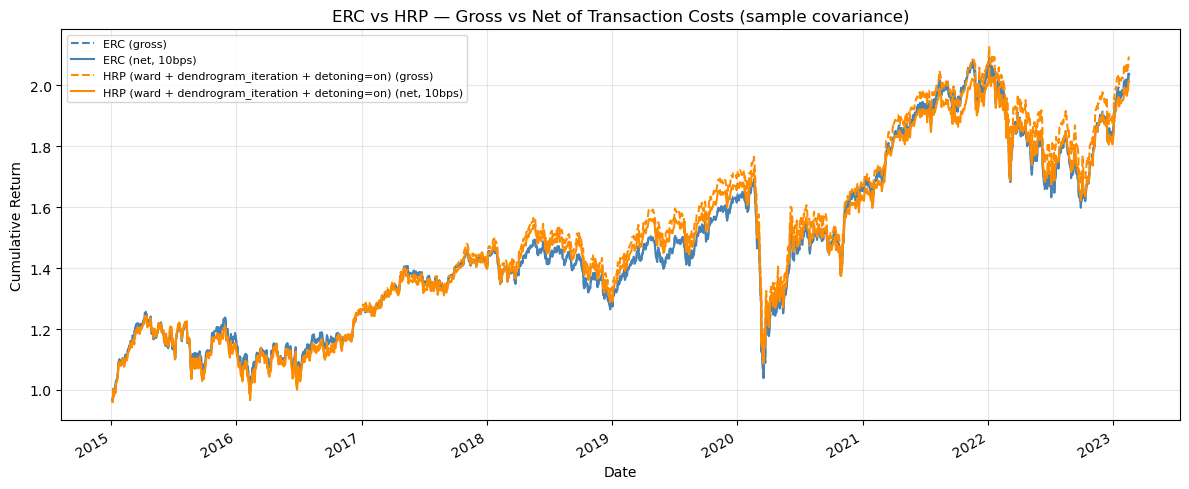

In [17]:
# === 3.c — Transaction cost impact: ERC vs HRP ===
TC_RATE = 10e-4  # 10 bps all-in, one-way

erc_cumrets_net = {
    est: backtest(erc_weights[est], performance, transaction_costs=TC_RATE)
    for est in COV_KEYS
}
hrp_cumrets_net = {
    est: backtest(hrp_weights_by_estimator[est], performance, transaction_costs=TC_RATE)
    for est in COV_KEYS
}

cost_summary_rows = []
for strat_name, gross_dict, net_dict, weights_dict in [
    ("ERC", erc_cumrets, erc_cumrets_net, erc_weights),
    (HRP_REP_LABEL, hrp_cumrets_by_est, hrp_cumrets_net, hrp_weights_by_estimator),
]:
    for est in COV_KEYS:
        gross_total_return = (gross_dict[est].iloc[-1] - 1) * 100
        net_total_return = (net_dict[est].iloc[-1] - 1) * 100
        avg_to = turnover(weights_dict[est].fillna(0.0)).mean() * 100
        cost_summary_rows.append({
            "Strategy": strat_name,
            "Estimator": estimator_display[est],
            "Total Return gross (%)": gross_total_return,
            "Total Return net (%)": net_total_return,
            "Cost drag (pp)": gross_total_return - net_total_return,
            "Avg Turnover (%)": avg_to,
        })

cost_summary = pd.DataFrame(cost_summary_rows).set_index(["Strategy", "Estimator"])
print(f"=== Gross vs net of {TC_RATE * 1e4:.0f}bps transaction costs ===")
print(cost_summary.round(2))

# Cumulative return, gross (dashed) vs net (solid), for the sample-covariance variant
fig, ax = plt.subplots(figsize=(12, 5))
erc_cumrets["sample"].plot(ax=ax, label="ERC (gross)", linestyle="--", color="steelblue")
erc_cumrets_net["sample"].plot(
    ax=ax, label=f"ERC (net, {TC_RATE * 1e4:.0f}bps)", color="steelblue"
)
hrp_cumrets_by_est["sample"].plot(
    ax=ax, label=f"{HRP_REP_LABEL} (gross)", linestyle="--", color="darkorange"
)
hrp_cumrets_net["sample"].plot(
    ax=ax, label=f"{HRP_REP_LABEL} (net, {TC_RATE * 1e4:.0f}bps)", color="darkorange"
)
ax.set_title("ERC vs HRP — Gross vs Net of Transaction Costs (sample covariance)")
ax.set_ylabel("Cumulative Return")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()